### Aplicação ANN for Regression

Vamos fazer a aplicação de uma ANN para regressão linear, considerando o método de perda MSE (já que temos predições contínuas de valores numéticos)

In [2]:
# import libraries
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

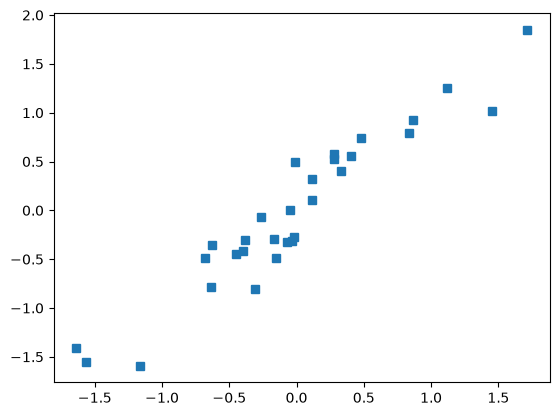

In [160]:
# create data

N = 30
x = torch.randn(N,1) # similar to Pandas, generate random numbers
y = x + torch.randn(N,1)/4

# plot the generated data
plt.plot(x,y,'s')
plt.show()

In [161]:
# build modelo ANN to regression simple

ANNreg = nn.Sequential(
    nn.Linear(1,1), # input layer
    nn.ReLU(),      # activation function
    nn.Linear(1,1)  # output layer
)

ANNreg

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [162]:
# learning rate
learning_rate = 0.05

# loss function
lossfun = nn.MSELoss()

# optimizer (the flavor of gradient descent to implement)
optimizer = torch.optim.SGD(ANNreg.parameters(),lr=learning_rate)

In [163]:
# train the model
numepochs = 300
losses = torch.zeros(numepochs)

## Train the model!
for epochi in range(numepochs):

    # foward pass
    yHat = ANNreg(x)
    
    # compute loss (MRE)
    loss = lossfun(yHat, y)
    losses[epochi] = loss

    #backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

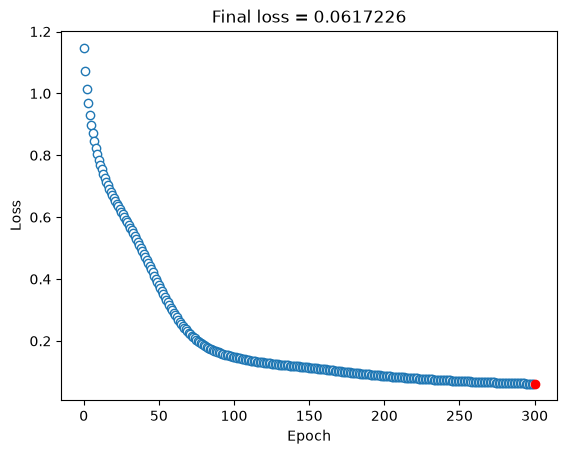

In [164]:
# show the losses

# manually compute losses
# final forward pass
predictions = ANNreg(x)

# final loss (MSE)
testloss = (predictions-y).pow(2).mean()

plt.plot(losses.detach(),'o', markerfacecolor='w', linewidth=.1)
plt.plot(numepochs,testloss.detach(),'ro')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final loss = %g' %testloss.item())
plt.show()

In [165]:
testloss.item()

0.06172260269522667

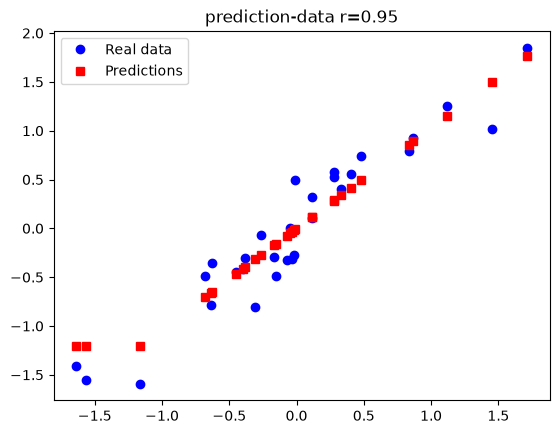

In [166]:
# plot the data
plt.plot(x,y, 'bo',label='Real data')
plt.plot(x,predictions.detach(),'rs',label='Predictions')
plt.title(f'prediction-data r={np.corrcoef(y.T,predictions.detach().T)[0,1]:.2f}')
plt.legend()
plt.show()

### Additional explorations

1) Quanto dado é "suficiente"? Experimente diferentes valores de N e observe quão baixa a perda (loss) fica.
   Você ainda obtém uma perda baixa ("baixa" é subjetivo, mas digamos perda < 0,25) com N=10? E com N=5?

2) Sua conclusão acima depende da quantidade de ruído nos dados? Tente alterar o nível de ruído
   modificando a divisão ("/2") ao criar y como x+randn.

3) Observe que o modelo nem sempre funciona bem. Coloque o código original (ou seja, N=30 e ruído /2)
   em uma função ou em um loop `for` e repita o treinamento 100 vezes (usando uma nova instância do modelo a cada vez).
   Em seguida, conte quantas vezes o modelo apresentou uma perda > 0,25.

---
Conforme diminuir o N, a função de perda fica cada vez menor. Para n=10, temos uma perda de 0,22, e n=5 a perda fica 0,11.

Quando alteramos o ruído pela metade (1/2), há um aumento na perda. Dessa forma, não só o número N de dados influencia a perda, mas também o nível de ruído.